In [1]:
import numpy as np
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import xarray as xr
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import lognorm
import cartopy as crs
import cartopy.crs as ccrs

In [2]:
def conccn(ds):
    ds = ( ds.assign
          (conccn = lambda ds : (((1-lognorm(1.59,ds.RDRY_NUS[:,:]*1e9).cdf(3.0))*ds.N_NUS[:,:]) + ds.N_AIS[:,:] + ds.N_ACS[:,:] + ds.N_COS[:,:] + ds.N_AII[:,:] + ds.N_ACI[:,:] + ds.N_COI[:,:]) * 1e-6))
    return(ds)


In [3]:
basecase_feb = xr.open_dataset('/home/chandras/mosaic-paper/sensitivityanalysis/mosaic-basecase/globvals/mosaic-basecase-202002-monmean.nc')
basecase_aug = xr.open_dataset('/home/chandras/mosaic-paper/sensitivityanalysis/mosaic-basecase/globvals/mosaic-basecase-202008-monmean.nc')
basecase_feb_conccn = conccn(basecase_feb)
basecase_aug_conccn = conccn(basecase_aug)
ci_feb = xr.open_dataset('/home/chandras/mosaic-paper/ci_202002_mean.nc')
ci_aug = xr.open_dataset('/home/chandras/mosaic-paper/ci_202008_mean.nc')
ci_extent_feb = ci_feb.ci>0.25
ci_extent_feb = ci_extent_feb.drop_vars('time')
ci_extent_aug = ci_aug.ci>0.25
ci_extent_aug = ci_extent_aug.drop_vars('time')
#np.where(ci_extent_feb)

/home/chandras/anaconda3/envs/ccnproj/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
module 'numpy' has no attribute 'cumproduct'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


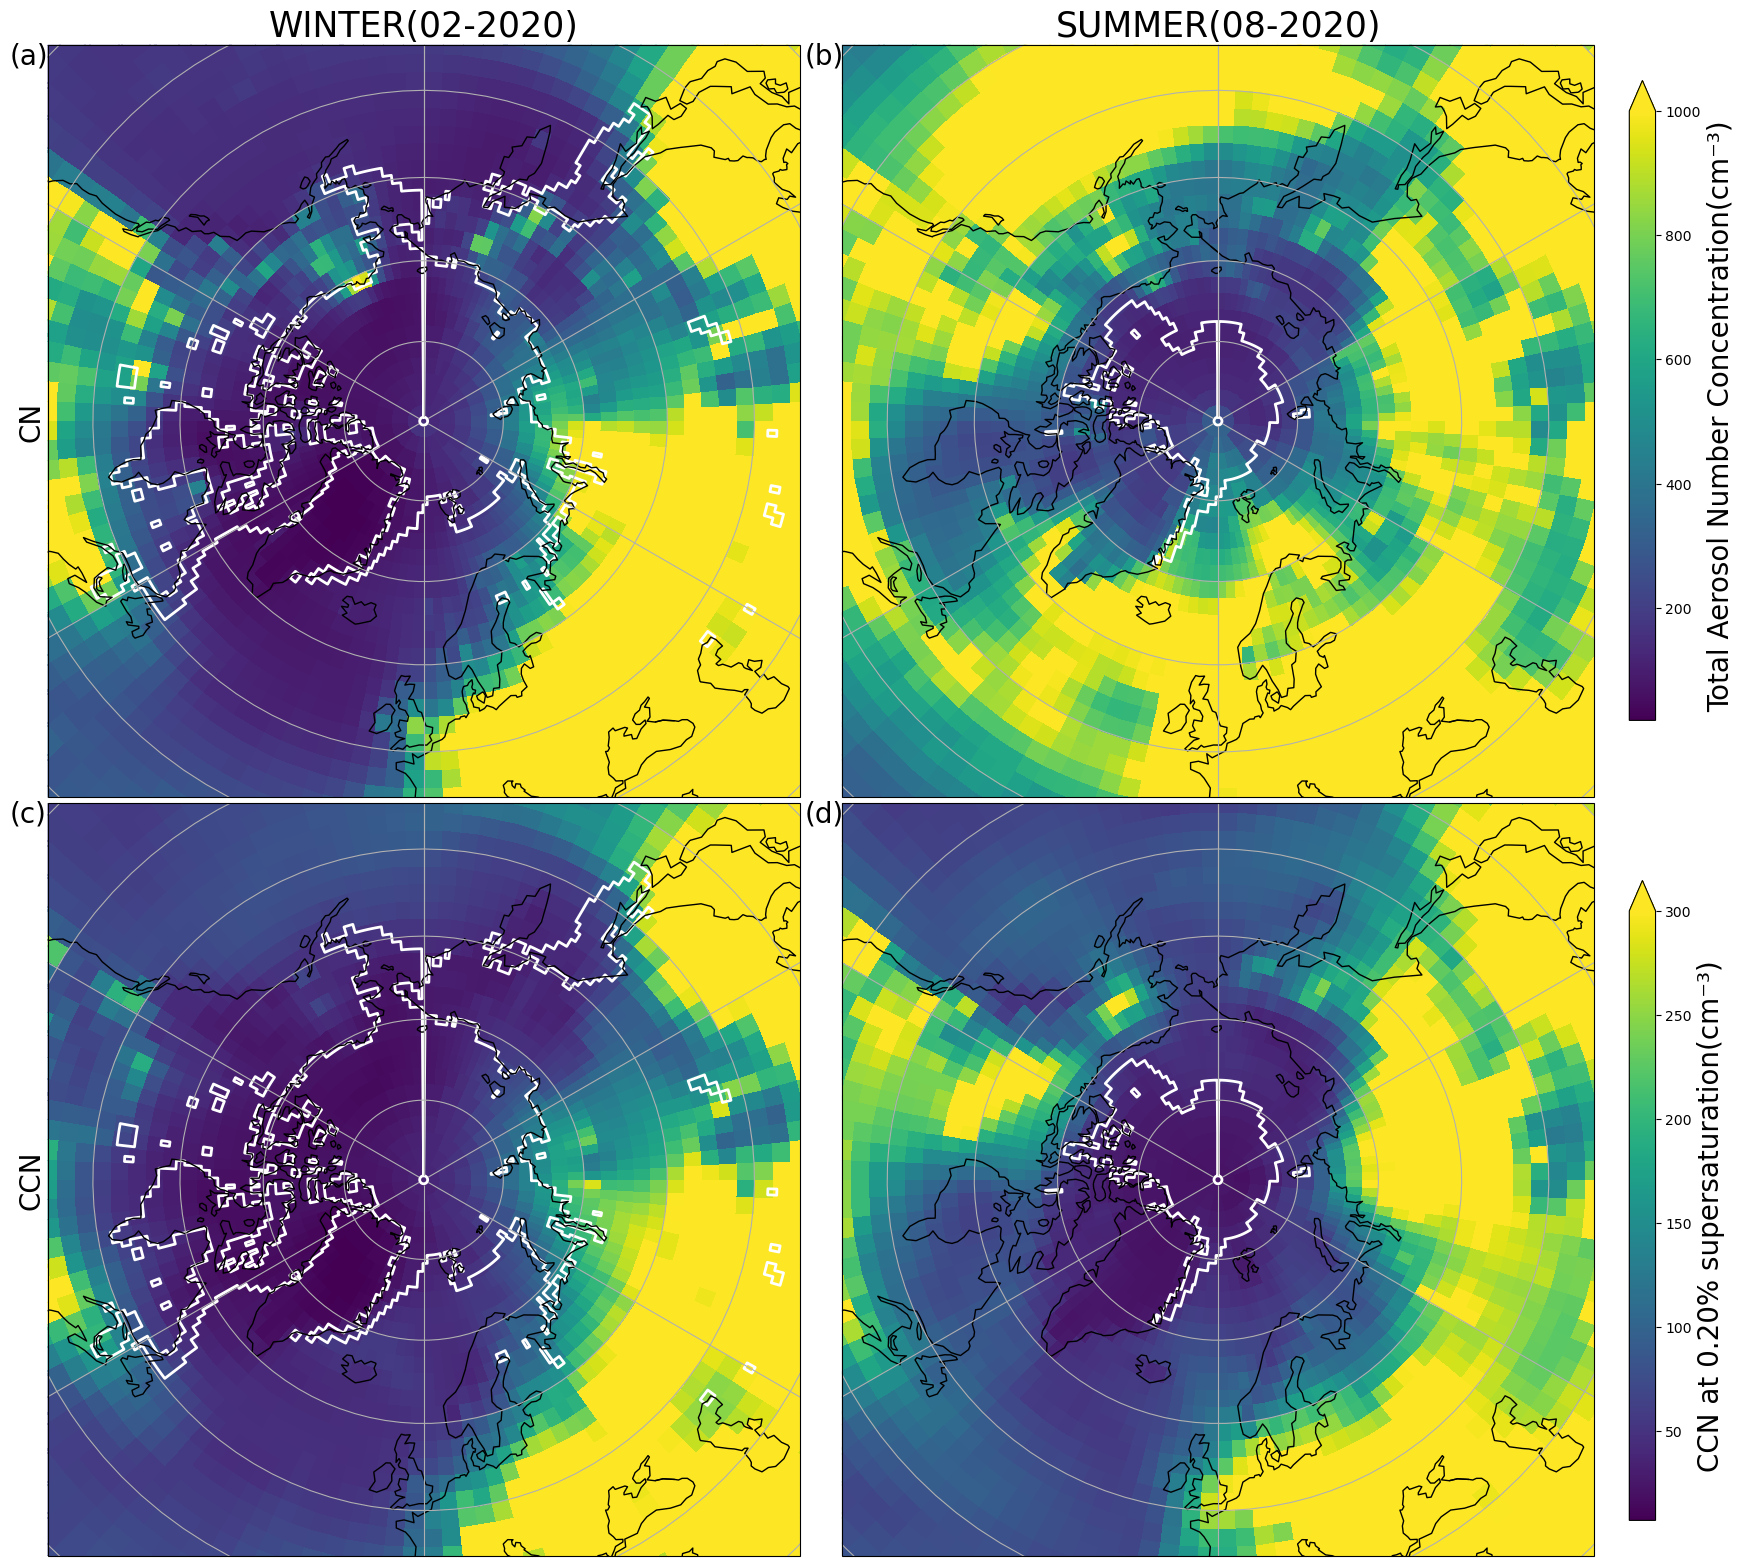

In [4]:
import cartopy.crs as ccrs
import shapely.geometry
import shapely.ops
fig, axis = plt.subplots(2, 2, figsize = (17.5,16),subplot_kw=dict(projection=ccrs.NorthPolarStereo()))
plot1 = basecase_feb_conccn.conccn[0,0,:,:].plot(ax=axis[0,0],transform=ccrs.PlateCarree(),vmax = 1000,add_colorbar =False)
plot2 = basecase_feb_conccn['CCN0.20'][0,0,:,:].plot(ax=axis[1,0],transform=ccrs.PlateCarree(),vmax = 300,add_colorbar = False)

xbound = ci_extent_feb.lon[:]
ybound  = ci_extent_feb.lat[:]
geoms = []
for yidx, xidx in zip(*np.where(ci_extent_feb[0,:,:])):
    if xidx >= 359:
        xidx = xidx - 359
    if yidx >=179:
        yidx = yidx-179
    geoms.append(shapely.geometry.box(xbound[xidx], ybound[yidx], xbound[xidx+1], ybound[yidx+1]))
full_geom = shapely.ops.unary_union(geoms)
axis[0,0].add_geometries(
    full_geom.geoms,
    crs=ccrs.PlateCarree(),
    facecolor = 'none',
    edgecolor='white',
    linewidth=2
)
axis[1,0].add_geometries(
    full_geom.geoms,
    crs=ccrs.PlateCarree(),
    facecolor = 'none',
    edgecolor='white',
    linewidth=2
)
plot1 = basecase_aug_conccn.conccn[0,0,:,:].plot(ax=axis[0,1],transform=ccrs.PlateCarree(),vmax = 1000,add_colorbar=False)
plot2 = basecase_aug_conccn['CCN0.20'][0,0,:,:].plot(ax=axis[1,1],transform=ccrs.PlateCarree(),vmax = 300,add_colorbar = False)
xbound = ci_extent_aug.lon[:]
ybound  = ci_extent_aug.lat[:]
geoms = []
for yidx, xidx in zip(*np.where(ci_extent_aug[0,:,:])):
    if xidx >= 359:
        xidx = xidx - 359
    if yidx >=179:
        yidx = yidx-179
    geoms.append(shapely.geometry.box(xbound[xidx], ybound[yidx], xbound[xidx+1], ybound[yidx+1]))
full_geom = shapely.ops.unary_union(geoms)
axis[0,1].add_geometries(
    full_geom.geoms,
    crs=ccrs.PlateCarree(),
    facecolor = 'none',
    edgecolor='white',
    linewidth=2
)
axis[1,1].add_geometries(
    full_geom.geoms,
    crs=ccrs.PlateCarree(),
    facecolor = 'none',
    edgecolor='white',
    linewidth=2
)

#axis[0,0].text(-0.07, 0.55, 'CN', va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=axis[0,0].transAxes,fontsize = 15)
#axis[1,0].text(-0.07, 0.55, 'CCN 0.20', va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=axis[1,0].transAxes,fontsize = 15)
exps = ['WINTER(02-2020)','SUMMER(08-2020)','','']
indices = ['(a)','(b)','(c)','(d)']
for i in range(2):
    for j in range(2):
        axis[i,j].coastlines()
        axis[i,j].set_extent([-180,180,90,45],ccrs.PlateCarree())
        axis[i,j].set_title(exps[(2*i)+j],size = 25)
        axis[i,j].gridlines()
        axis[i,j].text(-0.050, 0.975,indices[j+(2*i)],transform=axis[i,j].transAxes,size = 20)
axis[0,0].text(-0.040,0.5,'CN',transform=axis[0,0].transAxes,size = 20,rotation =  'vertical',verticalalignment ='center')
axis[1,0].text(-0.040,0.5,'CCN',transform=axis[1,0].transAxes,size = 20,rotation =  'vertical',verticalalignment ='center')
plt.subplots_adjust(top=1.0,bottom = 0.05)
plt.tight_layout()


fig.subplots_adjust(right=0.91)
cbar_ax = fig.add_axes([0.93, 0.55, 0.015, 0.4])
cbar = fig.colorbar(plot1, cax=cbar_ax,extend='max').set_label(label= 'Total Aerosol Number Concentration(cm⁻³)',size = 20)

cbar_ax = fig.add_axes([0.93, 0.05, 0.015, 0.4])
fig.colorbar(plot2, cax=cbar_ax,extend='max').set_label(label  = 'CCN at 0.20% supersaturation(cm⁻³)',fontsize = 20)
plt.savefig('../figures/basecase_spatial1.png',dpi = 300)